# Multi-dataset: Gene-Gene Covariation Analysis

This example demonstrates how to identify **cross-cell gene-gene covariation** across
multiple FOVs.

The multi-FOV version pools anchor–neighbor cell pairs across all FOVs within a condition,
increasing statistical power for detecting spatially-specific gene correlations.

**Dataset:** CODEX spatial proteomics — CLR vs DII immune subtypes

**Key API:**
- `spatial_query_multi.compute_gene_gene_correlation` — pools all non-anchor motif cell types together
- `spatial_query_multi.compute_gene_gene_correlation_by_type` — tests each non-anchor cell type separately

> **Note on this example dataset:** The CODEX panel contains only 56 protein markers primarily
> selected for cell type annotation, not for capturing intercellular signaling. This makes it
> suboptimal for covariation analysis. To demonstrate the workflow, we use a **relaxed significance
> threshold (`alpha=0.9`)** in this example to output covarying gene pairs. For your own data — 
> especially whole-transcriptomic platforms — use the **default `alpha=0.05`** or adjust based on
> your specific analysis needs.

## Setup

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import anndata as ad
import matplotlib.pyplot as plt

from SpatialQuery import spatial_query_multi

## Load Data & Initialize

In [3]:
DATA_DIR = "../data/codex_cancer"

adata = ad.read_h5ad(f"{DATA_DIR}/codex_data.h5ad")

adata

AnnData object with n_obs × n_vars = 258385 × 56
    obs: 'CellID', 'ClusterID', 'EventID', 'File Name', 'Region', 'TMA_AB', 'TMA_12', 'Index in File', 'groups', 'patients', 'spots', 'cell_id', 'size:size', 'HOECHST1_Cyc_1_ch_1', 'DRAQ5_Cyc_23_ch_4', 'Profile_Homogeneity:Fiter1', 'ClusterSize', 'ClusterName', 'neighborhood10', 'CD4+ICOS+', 'CD4+Ki67+', 'CD4+PD-1+', 'CD68+CD163+ICOS+', 'CD68+CD163+Ki67+', 'CD68+CD163+PD-1+', 'CD68+ICOS+', 'CD68+Ki67+', 'CD68+PD-1+', 'CD8+ICOS+', 'CD8+Ki67+', 'CD8+PD-1+', 'Treg-ICOS+', 'Treg-Ki67+', 'Treg-PD-1+', 'neighborhood number final', 'neighborhood name'
    var: 'marker_name', 'full_name', 'cell_type_annotation', 'cycle', 'channel'
    uns: 'data_source', 'groups_mapping', 'n_markers', 'technology'
    obsm: 'X_spatial_global', 'X_spatial_tile'

In [4]:
adata.X.max()

np.float32(54776.695)

Inspect `adata.obsm` for spatial coordinates, `adata.obs` for cell type labels and FOV identifiers, and `adata.var` for feature names. Then set the corresponding column names below.

In [5]:
# Assign immune subtype labels
adata.obs["state"] = "CLR"
adata.obs["state"][adata.obs["groups"] == 2] = "DII"

# Feature-wise z-score normalization for protein expression
adata.X = (adata.X - adata.X.mean(axis=0)) / adata.X.std(axis=0)


In [6]:
spatial_key = "X_spatial_tile"
label_key = "ClusterName"
feature_name = "marker_name"
fov_key = "File Name"

In [7]:
# Split data by FOV and immune subtype
clr_data = adata[adata.obs["state"] == "CLR"]
dii_data = adata[adata.obs["state"] == "DII"]

clr_datas = [clr_data[clr_data.obs[fov_key] == f] for f in clr_data.obs[fov_key].unique()]
dii_datas = [dii_data[dii_data.obs[fov_key] == f] for f in dii_data.obs[fov_key].unique()]

ds_names = ["CLR"] * len(clr_datas) + ["DII"] * len(dii_datas)
adata_fovs = clr_datas + dii_datas

print(f"CLR FOVs: {len(clr_datas)}, DII FOVs: {len(dii_datas)}")

CLR FOVs: 68, DII FOVs: 72


In [8]:
spm = spatial_query_multi(
    adatas=adata_fovs,
    datasets=ds_names,
    spatial_key=spatial_key,
    label_key=label_key,
    feature_name=feature_name,
    build_gene_index=False,
    if_lognorm=False,  # data is already z-score normalized
    if_normalize_spatial_coord=True,
)


Auto-normalizing spatial coordinates: mean nearest neighbor distance = 1.0
Scale factor: 0.0448
build_gene_index is False. Using adata.X for gene expression analysis.

Auto-normalizing spatial coordinates: mean nearest neighbor distance = 1.0
Scale factor: 0.0311
build_gene_index is False. Using adata.X for gene expression analysis.

Auto-normalizing spatial coordinates: mean nearest neighbor distance = 1.0
... (548 lines omitted) ...
Scale factor: 0.0421
build_gene_index is False. Using adata.X for gene expression analysis.


## Define Anchor and Motif

In [9]:
anchor_ct = "B cells"
motif = ["B cells", "CD4+ T cells CD45RO+", "CD8+ T cells"]
max_dist = 5
dii = "DII" 

## Method 1: Pooled Covariation (`compute_gene_gene_correlation`)

`compute_gene_gene_correlation` **pools all non-anchor cell types** in the motif into a
single neighbor group before computing correlations across FOVs. It performs two tests:

1. **Test 1 (spatial specificity):** correlation in motif+ anchor–neighbor pairs vs randomly paired cells
2. **Test 2 (motif specificity):** correlation in motif+ pairs vs motif− anchor–neighbor pairs

**Key parameters:**

| Parameter | Description |
|-----------|-------------|
| `ct` | Anchor cell type |
| `motif` | List of neighbor cell types forming the motif |
| `dataset` | Condition name(s) to restrict the analysis to |
| `max_dist` | Neighborhood radius (use either `max_dist` or `k`) |
| `k` | Number of nearest neighbors (use either `max_dist` or `k`) |
| `min_nonzero` | Minimum non-zero expression values required to include a gene |
| `alpha` | FDR significance threshold (default: 0.05) |

**Key output columns:**

| Column | Description |
|--------|-------------|
| `gene_center` | Gene expressed in the anchor cell |
| `gene_motif` | Gene expressed in the neighbor cell |
| `corr_neighbor` | Correlation between motif+ anchor–neighbor pairs |
| `corr_non_neighbor` | Correlation between randomly paired cells (Test 1 baseline) |
| `corr_center_no_motif` | Correlation for motif− anchors (Test 2 baseline) |
| `combined_score` | Combined effect size from both tests |
| `if_significant` | Whether the pair passes both FDR-corrected tests |

> **Note on equivalence:** Because covariation is computed between the **anchor type** and
> **non-anchor types in the motif**, when the motif contains only **one non-anchor cell type**,
> `compute_gene_gene_correlation` and `compute_gene_gene_correlation_by_type` produce
> equivalent results.

In [10]:
covarying_pooled = spm.compute_gene_gene_correlation(
    ct=anchor_ct,
    motif=motif,
    dataset=dii,
    max_dist=max_dist,
    alpha=0.9,  # relaxed for demo; use default 0.05 for real analysis
)

covarying_pooled_sig = covarying_pooled[covarying_pooled["if_significant"]].copy()
print(f"Total gene pairs tested: {len(covarying_pooled)}")
print(f"Significant covarying pairs (pooled): {len(covarying_pooled_sig)}")
covarying_pooled_sig.head(10)

Computing covarying genes using expression data ...
No genes specified. Using union of genes across all selected FOVs ...
Gene coverage: 56 genes in all FOVs, 56 genes total (union)
Analyzing 56 genes across 72 FOVs

Step 1: Computing and accumulating statistics across FOVs

--- Processing FOV 1/72: DII_0 ---
... (449 lines omitted) ...
Total gene pairs tested: 3136
Significant covarying pairs (pooled): 8


,gene_center,gene_motif,corr_neighbor,corr_non_neighbor,p_value_test1,delta_corr_test1,corr_center_no_motif,p_value_test2,delta_corr_test2,combined_score,adj-pval-test1,adj-pval-test2,if_significant
0,CD21,CD21,0.196482,-0.005108,7.456897e-07,0.201590,0.045784,0.000806,0.150699,0.696930,0.002534,0.198643,True
1,CD20,CD21,0.155435,-0.005492,8.442866e-05,0.160926,0.016589,0.002188,0.138845,0.455191,0.050537,0.311026,True
4,aSMA,Podoplanin,0.134074,-0.004457,7.314500e-04,0.138531,0.005746,0.004750,0.128327,0.339023,0.198643,0.537893,True
5,CD20,CD20,0.131804,-0.015363,3.359355e-04,0.147167,0.014495,0.009831,0.117309,0.318205,0.140757,0.764281,True
7,CD21,CD20,0.123396,-0.013967,8.232068e-04,0.137363,0.010758,0.013266,0.112638,0.275126,0.198643,0.789508,True
8,T-bet,ICOS,0.125503,-0.009843,9.780419e-04,0.135346,0.015980,0.015990,0.109523,0.259908,0.198643,0.847418,True
10,CD21,CD11c,0.103233,-0.001601,1.077235e-02,0.104834,-0.015701,0.009094,0.118934,0.231826,0.765020,0.747140,True
13,CD20,CD11c,0.106835,-0.001038,8.674002e-03,0.107873,-0.005156,0.013989,0.111991,0.212081,0.726881,0.792103,True


### Top Frequent Genes in Covarying Pairs (Pooled)

Visualize the top 20 most frequently appearing genes on the anchor side (`gene_center`)
and the motif side (`gene_motif`) among significant covarying pairs.


In [11]:
covarying_pooled_sig

,gene_center,gene_motif,corr_neighbor,corr_non_neighbor,p_value_test1,delta_corr_test1,corr_center_no_motif,p_value_test2,delta_corr_test2,combined_score,adj-pval-test1,adj-pval-test2,if_significant
0,CD21,CD21,0.196482,-0.005108,7.456897e-07,0.201590,0.045784,0.000806,0.150699,0.696930,0.002534,0.198643,True
1,CD20,CD21,0.155435,-0.005492,8.442866e-05,0.160926,0.016589,0.002188,0.138845,0.455191,0.050537,0.311026,True
4,aSMA,Podoplanin,0.134074,-0.004457,7.314500e-04,0.138531,0.005746,0.004750,0.128327,0.339023,0.198643,0.537893,True
5,CD20,CD20,0.131804,-0.015363,3.359355e-04,0.147167,0.014495,0.009831,0.117309,0.318205,0.140757,0.764281,True
7,CD21,CD20,0.123396,-0.013967,8.232068e-04,0.137363,0.010758,0.013266,0.112638,0.275126,0.198643,0.789508,True
8,T-bet,ICOS,0.125503,-0.009843,9.780419e-04,0.135346,0.015980,0.015990,0.109523,0.259908,0.198643,0.847418,True
10,CD21,CD11c,0.103233,-0.001601,1.077235e-02,0.104834,-0.015701,0.009094,0.118934,0.231826,0.765020,0.747140,True
13,CD20,CD11c,0.106835,-0.001038,8.674002e-03,0.107873,-0.005156,0.013989,0.111991,0.212081,0.726881,0.792103,True


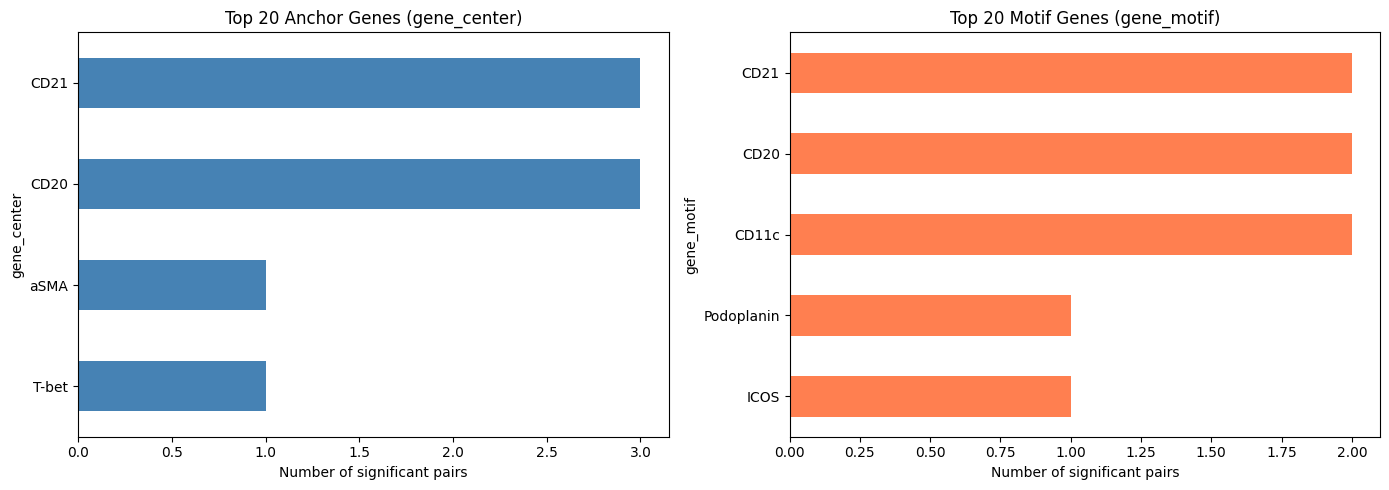

In [12]:
top_n = 20

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

covarying_pooled_sig["gene_center"].value_counts().head(top_n).plot.barh(
    ax=axes[0], color="steelblue")
axes[0].set_title(f"Top {top_n} Anchor Genes (gene_center)")
axes[0].set_xlabel("Number of significant pairs")
axes[0].invert_yaxis()

covarying_pooled_sig["gene_motif"].value_counts().head(top_n).plot.barh(
    ax=axes[1], color="coral")
axes[1].set_title(f"Top {top_n} Motif Genes (gene_motif)")
axes[1].set_xlabel("Number of significant pairs")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


## Method 2: Per-cell-type Covariation (`compute_gene_gene_correlation_by_type`)

`compute_gene_gene_correlation_by_type` in the multi-FOV setting works the same as the
single-dataset version, but pools cell pairs across all FOVs in the specified condition.
It tests each **non-anchor cell type separately**, so the output includes a `cell_type` column.

**Key parameters:**

| Parameter | Description |
|-----------|-------------|
| `ct` | Anchor cell type |
| `motif` | List of neighbor cell types forming the motif |
| `dataset` | Condition name(s) to restrict the analysis to. If `None`, uses all datasets |
| `genes` | List of genes to analyze. If `None`, uses intersection of genes across FOVs |
| `max_dist` | Neighborhood radius (use either `max_dist` or `k`) |
| `k` | Number of nearest neighbors (use either `max_dist` or `k`) |
| `min_size` | Minimum neighborhood size for each anchor cell |
| `min_nonzero` | Minimum non-zero expression values required to include a gene |
| `alpha` | FDR significance threshold (default: 0.05) |

**Key output columns:**

| Column | Description |
|--------|-------------|
| `cell_type` | The neighbor cell type in the pair |
| `gene_center` | Gene expressed in the anchor cell |
| `gene_motif` | Gene expressed in the neighbor cell |
| `corr_neighbor` | Correlation between motif+ anchor–neighbor pairs |
| `corr_non_neighbor` | Correlation between randomly paired cells (Test 1 baseline) |
| `corr_center_no_motif` | Correlation for motif− anchors (Test 2 baseline) |
| `combined_score` | Combined effect size from both tests |
| `if_significant` | Whether the pair passes both FDR-corrected tests |

> **Tip:** For whole-transcriptomic data (e.g., MERFISH, Slide-seq), pre-select highly
> variable genes via the `genes` parameter to improve speed. For targeted panels like CODEX
> (tens of markers), this is not necessary.

In [13]:
covarying = spm.compute_gene_gene_correlation_by_type(
    ct=anchor_ct,
    motif=motif,
    dataset=dii,
    max_dist=max_dist,
    alpha=0.9,  # relaxed for demo; use default 0.05 for real analysis
)

covarying_sig = covarying[covarying["if_significant"]].copy()
print(f"Total gene pairs tested: {len(covarying)}")
print(f"Significant covarying pairs: {len(covarying_sig)}")

Computing covarying genes using expression data ...
Analyzing 2 non-center cell types in motif: ['CD4+ T cells CD45RO+', 'CD8+ T cells']
Selected 72 FOVs for analysis
No genes specified. Using union of genes across all selected FOVs ...
Gene coverage: 56 genes in all FOVs, 56 genes total (union)
Analyzing 56 genes across 72 FOVs

Step 1: Computing Correlation-3 (Center without motif vs Neighbors)
... (365 lines omitted) ...
Total gene pairs tested: 4385
Significant covarying pairs: 16


### Top Frequent Genes in Covarying Pairs (Per Cell Type)

For `compute_gene_gene_correlation_by_type`, visualize the top 20 genes
separately for each neighbor cell type.


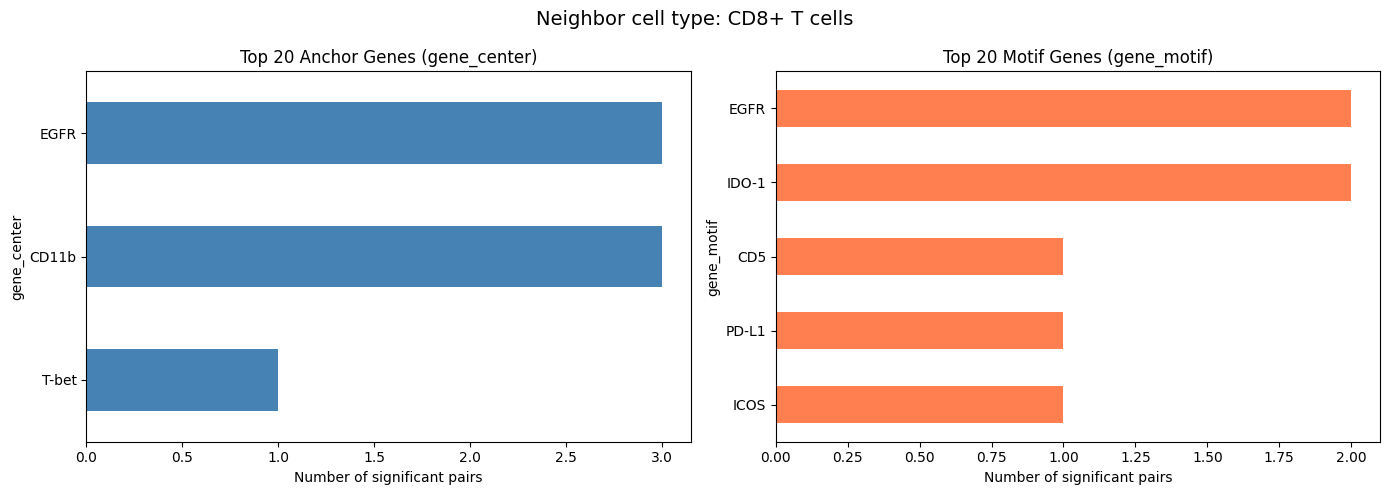

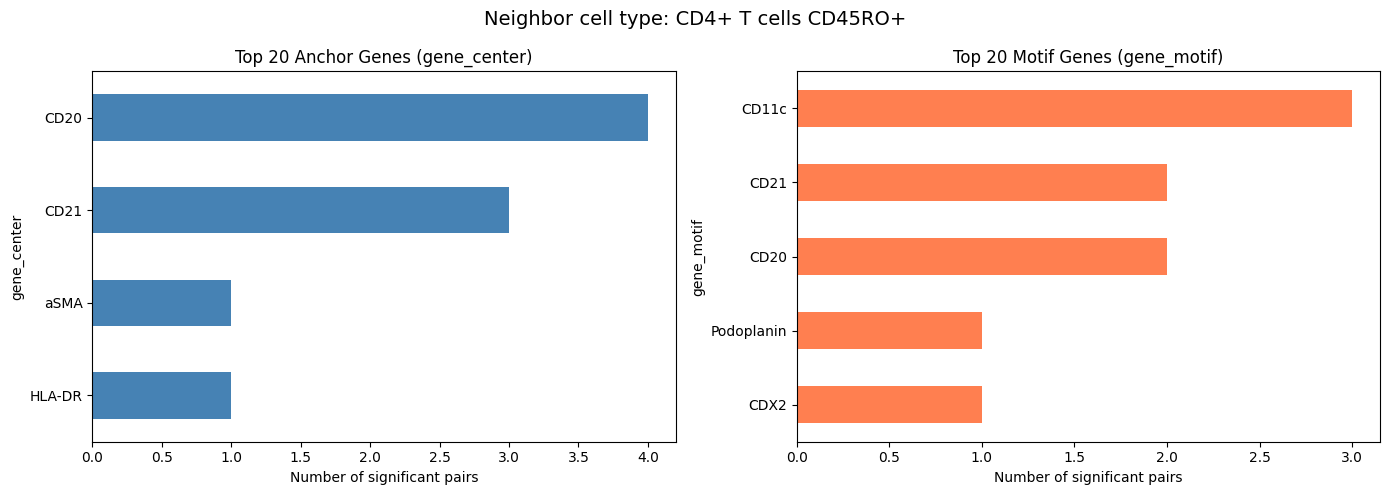

In [14]:
top_n = 20
cell_types = covarying_sig["cell_type"].unique()

for ct in cell_types:
    ct_df = covarying_sig[covarying_sig["cell_type"] == ct]
    if len(ct_df) == 0:
        continue

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Neighbor cell type: {ct}", fontsize=14)

    ct_df["gene_center"].value_counts().head(top_n).plot.barh(
        ax=axes[0], color="steelblue")
    axes[0].set_title(f"Top {top_n} Anchor Genes (gene_center)")
    axes[0].set_xlabel("Number of significant pairs")
    axes[0].invert_yaxis()

    ct_df["gene_motif"].value_counts().head(top_n).plot.barh(
        ax=axes[1], color="coral")
    axes[1].set_title(f"Top {top_n} Motif Genes (gene_motif)")
    axes[1].set_xlabel("Number of significant pairs")
    axes[1].invert_yaxis()

    plt.tight_layout()
    plt.show()


## Summary by Neighbor Cell Type

In [15]:
covarying_sig["cell_type"].value_counts()

cell_type
CD4+ T cells CD45RO+    9
CD8+ T cells            7
Name: count, dtype: int64

## Inspect Top Covarying Gene Pairs

Sort by combined score (absolute value) to see the strongest associations.

In [16]:
covarying_sig.sort_values("abs_combined_score", ascending=False).head(15)[
    ["cell_type", "gene_center", "gene_motif", "corr_neighbor", "corr_non_neighbor",
     "combined_score", "q_value_test1", "q_value_test2"]
]

,cell_type,gene_center,gene_motif,corr_neighbor,corr_non_neighbor,combined_score,q_value_test1,q_value_test2
0,CD8+ T cells,EGFR,EGFR,0.245635,-0.019511,0.968876,0.000057,0.230913
1,CD4+ T cells CD45RO+,CD21,CD21,0.223379,-0.008160,0.879733,0.002289,0.094890
2,CD8+ T cells,CD11b,IDO-1,0.208581,-0.033683,0.799386,0.000600,0.255575
3,CD4+ T cells CD45RO+,CD20,CD21,0.195619,-0.008602,0.756938,0.015660,0.094890
4,CD4+ T cells CD45RO+,CD21,CD11c,0.161783,-0.003095,0.608689,0.151142,0.096347
5,CD4+ T cells CD45RO+,CD20,CD11c,0.166926,-0.002746,0.587049,0.114299,0.134287
6,CD8+ T cells,CD11b,EGFR,0.194028,-0.016495,0.554852,0.009759,0.518023
7,CD8+ T cells,EGFR,CD5,0.192606,-0.016476,0.521830,0.009759,0.679914
8,CD8+ T cells,EGFR,IDO-1,0.168426,-0.034548,0.454796,0.013947,0.874555
9,CD8+ T cells,CD11b,PD-L1,0.165475,-0.022802,0.414831,0.028668,0.781488


## Visualize Covarying Gene Modules

> **Note:** `plot_gene_pair_heatmap` is available on the single-dataset `spatial_query` class.
> For multi-dataset results, you can use the standalone plotting function from `SpatialQuery.plotting`
> or apply clustering directly to the result DataFrame.

CD8+ T cells: Skipping neg with 0 rows and 0 columns.
CD4+ T cells CD45RO+: Skipping neg with 1 rows and 1 columns.


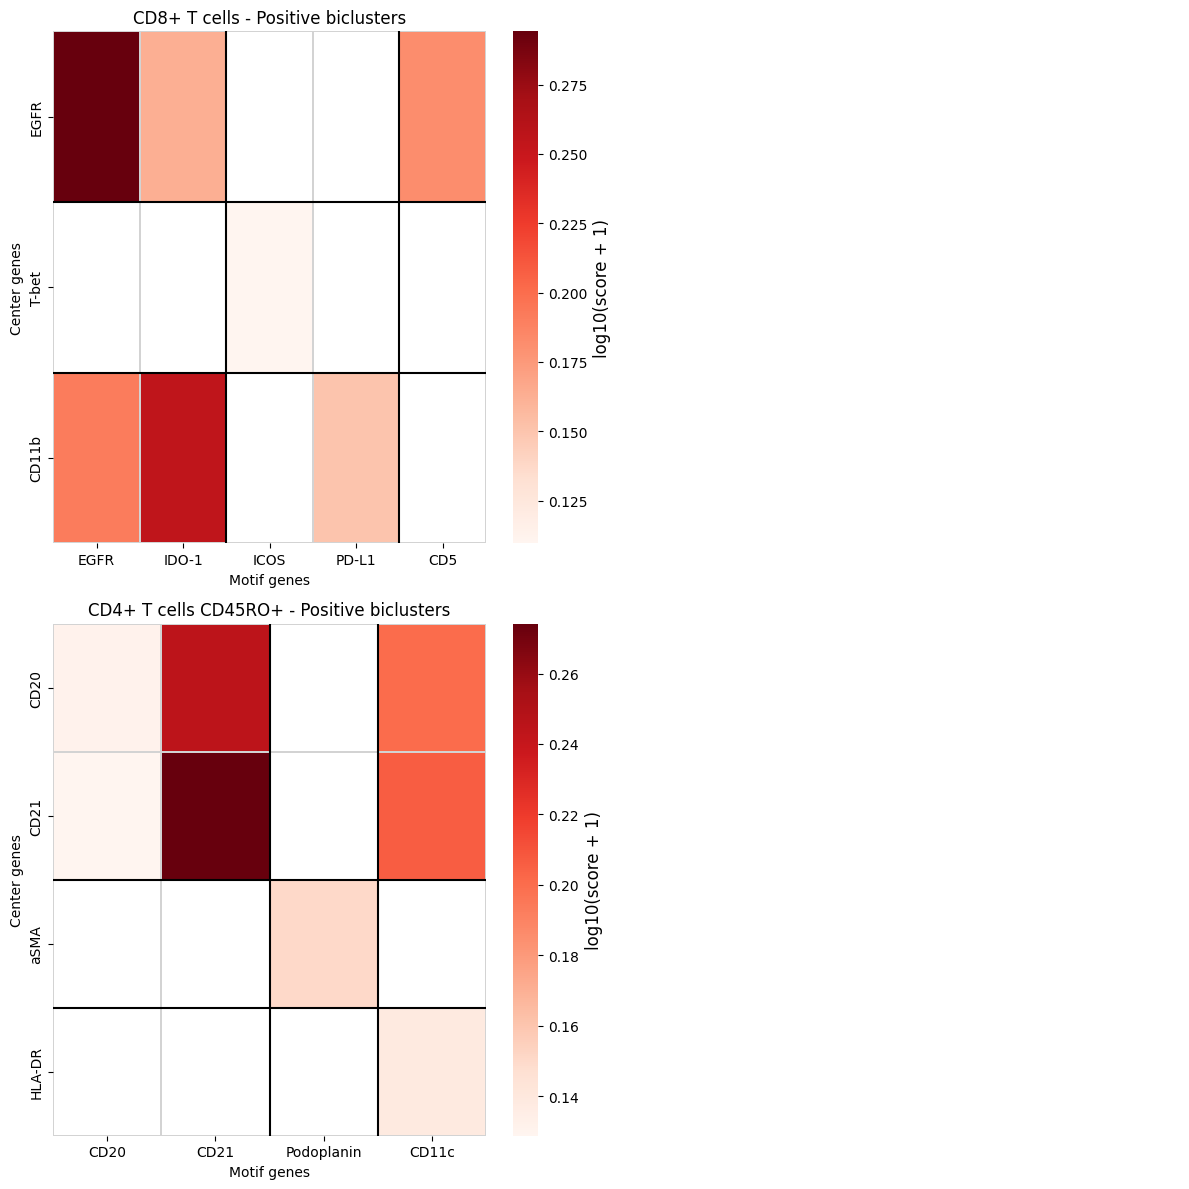

In [17]:
from SpatialQuery.plotting import plot_gene_pair_heatmap

if len(covarying_sig) > 0:
    modules = plot_gene_pair_heatmap(
        gene_pair_df=covarying_sig,
        figsize=(12, 6),
    )
    modules.head(10)
else:
    print("No significant covarying gene pairs found.")